# Partie II — CNN : Classification d'Images Alimentaires (Food-101)
## Objectif
Classifier des images de plats de nourriture parmi **N categories** (selon le dataset charge)
en utilisant un Reseau de Neurones Convolutif (CNN) implementé avec PyTorch.

### Pourquoi le MLP est inadapte aux images ?
| Probleme | MLP | CNN |
|---|---|---|
| Structure spatiale | Detruite par le flatten | Preservee par les filtres |
| Nombre de parametres | Excessif (ex: 150K+ pour 224x224) | Reduit par le partage des poids |
| Generalisation | Surapprentissage rapide | Bonne grace a la localite des filtres |

### Les 3 idees fondatrices des CNN
1. **Localite** : Chaque filtre ne regarde qu'une petite region (ex: 3x3 pixels)
2. **Partage des poids** : Le meme filtre glisse sur toute l'image — drastiquement moins de parametres
3. **Hierarchie** : couches basses = bords/couleurs, couches hautes = formes/objets complexes


## Etape 1 — Imports et Implementations Manuelles des Primitives CNN

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
import os

torch.manual_seed(42)
np.random.seed(42)
print("Imports OK")


Imports OK


### 1a. Implementation manuelle de la Correlation Croisee 2D
La convolution en Deep Learning est en realite une **correlation croisee** (pas de retournement du filtre).

In [2]:
def correlation_croisee_2d(image, filtre):
    h_f, w_f = filtre.shape
    h_img, w_img = image.shape
    sortie = torch.zeros((h_img - h_f + 1, w_img - w_f + 1))
    for i in range(sortie.shape[0]):
        for j in range(sortie.shape[1]):
            region = image[i:i+h_f, j:j+w_f]
            sortie[i, j] = (region * filtre).sum()
    return sortie

def max_pooling_2d(image, taille_pool=2):
    h_img, w_img = image.shape
    sortie = torch.zeros((h_img // taille_pool, w_img // taille_pool))
    for i in range(sortie.shape[0]):
        for j in range(sortie.shape[1]):
            region = image[i*taille_pool:(i+1)*taille_pool, j*taille_pool:(j+1)*taille_pool]
            sortie[i, j] = region.max()
    return sortie

def avg_pooling_2d(image, taille_pool=2):
    h_img, w_img = image.shape
    sortie = torch.zeros((h_img // taille_pool, w_img // taille_pool))
    for i in range(sortie.shape[0]):
        for j in range(sortie.shape[1]):
            region = image[i*taille_pool:(i+1)*taille_pool, j*taille_pool:(j+1)*taille_pool]
            sortie[i, j] = region.mean()
    return sortie

# --- Verification avec PyTorch ---
X = torch.tensor([[0.,1.,2.,3.,4.],
                  [5.,6.,7.,8.,9.],
                  [1.,2.,3.,4.,5.],
                  [6.,7.,8.,9.,0.],
                  [1.,2.,3.,4.,5.]])
K = torch.tensor([[0.,1.,0.],
                  [1.,2.,1.],
                  [0.,1.,0.]])

print("--- Correlation Croisee 2D ---")
m = correlation_croisee_2d(X, K)
p = F.conv2d(X.unsqueeze(0).unsqueeze(0), K.unsqueeze(0).unsqueeze(0)).squeeze()
print("Manuelle  :", m)
print("PyTorch   :", p)
print("Identique ?", torch.allclose(m, p))

print("\n--- Max Pooling 2D (2x2) ---")
X4 = X[:4, :4]
print("Manuel  :", max_pooling_2d(X4, 2))
print("PyTorch :", F.max_pool2d(X4.unsqueeze(0).unsqueeze(0), 2).squeeze())

print("\n--- Avg Pooling 2D (2x2) ---")
print("Manuel  :", avg_pooling_2d(X4, 2))
print("PyTorch :", F.avg_pool2d(X4.unsqueeze(0).unsqueeze(0), 2).squeeze())


--- Correlation Croisee 2D ---
Manuelle  : tensor([[27., 33., 39.],
        [21., 27., 33.],
        [32., 38., 34.]])
PyTorch   : tensor([[27., 33., 39.],
        [21., 27., 33.],
        [32., 38., 34.]])
Identique ? True

--- Max Pooling 2D (2x2) ---
Manuel  : tensor([[6., 8.],
        [7., 9.]])
PyTorch : tensor([[6., 8.],
        [7., 9.]])

--- Avg Pooling 2D (2x2) ---
Manuel  : tensor([[3., 5.],
        [4., 6.]])
PyTorch : tensor([[3., 5.],
        [4., 6.]])


## Etape 2 — Architecture CNN (Inspiree de LeNet)
### Calcul des dimensions
Pour une image d'entree **3 x 128 x 128** :
- Apres Conv1 + MaxPool : 16 x 64 x 64
- Apres Conv2 + MaxPool : 32 x 32 x 32
- Apres Conv3 + MaxPool : 64 x 16 x 16
- Apres Flatten         : 64 * 16 * 16 = **16 384 neurones**


In [3]:
class FoodCNN(nn.Module):
    def __init__(self, num_classes):
        super(FoodCNN, self).__init__()

        # --- Bloc Extraction de Caracteristiques ---
        self.features = nn.Sequential(
            # Bloc 1 : detection des bords et textures
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 128x128 -> 64x64

            # Bloc 2 : detection des formes
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 64x64 -> 32x32

            # Bloc 3 : detection d'objets complexes
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 32x32 -> 16x16
        )

        # --- Bloc Classificateur ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Verification de l'architecture sur une image fictive
image_test = torch.randn(1, 3, 128, 128)
model_tmp = FoodCNN(num_classes=10)
out = model_tmp(image_test)
print(f"Entree : {image_test.shape}  ->  Sortie : {out.shape}")
print("Architecture FoodCNN creee avec succes !")
print(model_tmp)
params = sum(p.numel() for p in model_tmp.parameters() if p.requires_grad)
print(f"\nParametres totaux : {params:,}")


Entree : torch.Size([1, 3, 128, 128])  ->  Sortie : torch.Size([1, 10])
Architecture FoodCNN creee avec succes !
FoodCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequen

## Etape 3 — Etude des Hyperparametres Architecturaux

In [4]:
image_test = torch.randn(1, 3, 128, 128)

print("1. INFLUENCE DU PADDING")
c_no_pad  = nn.Conv2d(3, 16, 3, padding=0)
c_pad     = nn.Conv2d(3, 16, 3, padding=1)
print(f"   Sans padding : {c_no_pad(image_test).shape}  (perte des bordures)")
print(f"   Avec padding=1 : {c_pad(image_test).shape}  (taille conservee)")

print("\n2. INFLUENCE DU STRIDE")
c_s1 = nn.Conv2d(3, 16, 3, padding=1, stride=1)
c_s2 = nn.Conv2d(3, 16, 3, padding=1, stride=2)
print(f"   Stride=1 : {c_s1(image_test).shape}")
print(f"   Stride=2 : {c_s2(image_test).shape}  (reduit la taille par 2 sans pooling)")

print("\n3. MAX POOLING vs AVERAGE POOLING")
x_feat = c_pad(image_test)
mp = nn.MaxPool2d(2)(x_feat)
ap = nn.AvgPool2d(2)(x_feat)
print(f"   Max Pooling : {mp.shape}  (garde les activations fortes - bords)")
print(f"   Avg Pooling : {ap.shape}  (moyenne - lisse davantage)")

print("\n4. INFLUENCE DU NOMBRE DE FILTRES")
c16 = nn.Conv2d(3, 16, 3);  c64 = nn.Conv2d(3, 64, 3)
p16 = sum(p.numel() for p in c16.parameters())
p64 = sum(p.numel() for p in c64.parameters())
print(f"   16 filtres : {p16:,} parametres")
print(f"   64 filtres : {p64:,} parametres  (x{p64//p16} fois plus)")

print("\n5. CONVOLUTION 1x1 — Reduction de dimensionnalite")
c64_out = nn.Conv2d(3, 64, 3)(image_test)     # [1, 64, 126, 126]
c1x1    = nn.Conv2d(64, 16, 1)
out_1x1 = c1x1(c64_out)
print(f"   Entree (64 canaux) : {c64_out.shape}")
print(f"   Apres Conv 1x1 (16 canaux) : {out_1x1.shape}  (meme taille spatiale, moins de canaux)")


1. INFLUENCE DU PADDING
   Sans padding : torch.Size([1, 16, 126, 126])  (perte des bordures)
   Avec padding=1 : torch.Size([1, 16, 128, 128])  (taille conservee)

2. INFLUENCE DU STRIDE
   Stride=1 : torch.Size([1, 16, 128, 128])
   Stride=2 : torch.Size([1, 16, 64, 64])  (reduit la taille par 2 sans pooling)

3. MAX POOLING vs AVERAGE POOLING
   Max Pooling : torch.Size([1, 16, 64, 64])  (garde les activations fortes - bords)
   Avg Pooling : torch.Size([1, 16, 64, 64])  (moyenne - lisse davantage)

4. INFLUENCE DU NOMBRE DE FILTRES
   16 filtres : 448 parametres
   64 filtres : 1,792 parametres  (x4 fois plus)

5. CONVOLUTION 1x1 — Reduction de dimensionnalite
   Entree (64 canaux) : torch.Size([1, 64, 126, 126])
   Apres Conv 1x1 (16 canaux) : torch.Size([1, 16, 126, 126])  (meme taille spatiale, moins de canaux)


## Etape 4 — Chargement du Dataset Food-101

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

transformations = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),         # Data augmentation
    transforms.ColorJitter(brightness=0.2),    # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

chemin_train = 'data/food101-25-class/train'
chemin_test  = 'data/food101-25-class/test'

try:
    dataset_train = datasets.ImageFolder(root=chemin_train, transform=transformations)
    dataset_test  = datasets.ImageFolder(root=chemin_test,  transform=transformations)

    NUM_CLASSES = len(dataset_train.classes)  # Detecte automatiquement le nombre de classes

    train_loader_cnn = DataLoader(dataset_train, batch_size=32, shuffle=True,  num_workers=0)
    test_loader_cnn  = DataLoader(dataset_test,  batch_size=32, shuffle=False, num_workers=0)

    print(f"Dataset charge avec succes !")
    print(f"  Nombre de classes detectees : {NUM_CLASSES}")
    print(f"  Classes : {dataset_train.classes}")
    print(f"  Images train : {len(dataset_train)}")
    print(f"  Images test  : {len(dataset_test)}")

except FileNotFoundError as e:
    print("Erreur : dossier introuvable.")
    print("Verifiez que 'data/food101-25-class/train' et '/test' existent.")
    print(e)
    NUM_CLASSES = None


Device : cpu


Dataset charge avec succes !
  Nombre de classes detectees : 19
  Classes : ['apple_pie', 'bibimbap', 'caesar_salad', 'cheesecake', 'chicken_wings', 'cup_cakes', 'donuts', 'dumplings', 'fish_and_chips', 'french_fries', 'french_toast', 'fried_rice', 'hamburger', 'hot_dog', 'ice_cream', 'onion_rings', 'peking_duck', 'pizza', 'ramen']
  Images train : 14159
  Images test  : 357


## Etape 5 — Entrainement du CNN
Le modele est cree avec **NUM_CLASSES classes** detectees automatiquement — plus de bug avec 25 vs 19.


In [6]:
if NUM_CLASSES is None:
    print("Dataset non charge — entrainement impossible.")
else:
    # Creation du modele avec le bon nombre de classes
    model_cnn = FoodCNN(num_classes=NUM_CLASSES).to(device)
    print(f"Modele cree pour {NUM_CLASSES} classes")
    print(f"Parametres totaux : {sum(p.numel() for p in model_cnn.parameters() if p.requires_grad):,}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    EPOCHS = 10
    train_losses, test_losses = [], []
    train_accs,   test_accs   = [], []

    print(f"\nEntrainement sur {EPOCHS} epoques...\n")
    for epoch in range(EPOCHS):
        # --- Phase Train ---
        model_cnn.train()
        running_loss, correct, total = 0.0, 0, 0
        t0 = time.time()

        for i, (images, labels) in enumerate(train_loader_cnn):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model_cnn(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

        scheduler.step()

        train_losses.append(running_loss / len(train_loader_cnn))
        train_accs.append(100.0 * correct / total)

        # --- Phase Test ---
        model_cnn.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader_cnn:
                images, labels = images.to(device), labels.to(device)
                outputs = model_cnn(images)
                val_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total   += labels.size(0)

        test_losses.append(val_loss / len(test_loader_cnn))
        test_accs.append(100.0 * val_correct / val_total)

        elapsed = time.time() - t0
        print(f"Ep {epoch+1:02d}/{EPOCHS} [{elapsed:.1f}s] | "
              f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.2f}% | "
              f"Test  Loss: {test_losses[-1]:.4f} Acc: {test_accs[-1]:.2f}%")

    print("\nEntrainement termine !")


Modele cree pour 19 classes
Parametres totaux : 4,223,251

Entrainement sur 10 epoques...

Ep 01/10 [297.5s] | Train Loss: 2.9679 Acc: 7.70% | Test  Loss: 2.8655 Acc: 0.00%
Ep 02/10 [290.0s] | Train Loss: 2.8481 Acc: 8.09% | Test  Loss: 2.6802 Acc: 12.32%
Ep 03/10 [283.2s] | Train Loss: 2.8357 Acc: 8.50% | Test  Loss: 2.7402 Acc: 20.17%
Ep 04/10 [463.9s] | Train Loss: 2.8167 Acc: 8.80% | Test  Loss: 2.6688 Acc: 1.68%
Ep 05/10 [513.9s] | Train Loss: 2.8129 Acc: 9.27% | Test  Loss: 2.7325 Acc: 0.00%
Ep 06/10 [513.4s] | Train Loss: 2.7897 Acc: 9.73% | Test  Loss: 2.6702 Acc: 0.00%
Ep 07/10 [369.6s] | Train Loss: 2.7648 Acc: 10.57% | Test  Loss: 2.6548 Acc: 1.96%
Ep 08/10 [355.9s] | Train Loss: 2.7312 Acc: 10.71% | Test  Loss: 2.8994 Acc: 0.28%
Ep 09/10 [380.1s] | Train Loss: 2.7057 Acc: 11.42% | Test  Loss: 2.6436 Acc: 5.32%
Ep 10/10 [352.4s] | Train Loss: 2.6803 Acc: 12.15% | Test  Loss: 2.6779 Acc: 1.12%

Entrainement termine !


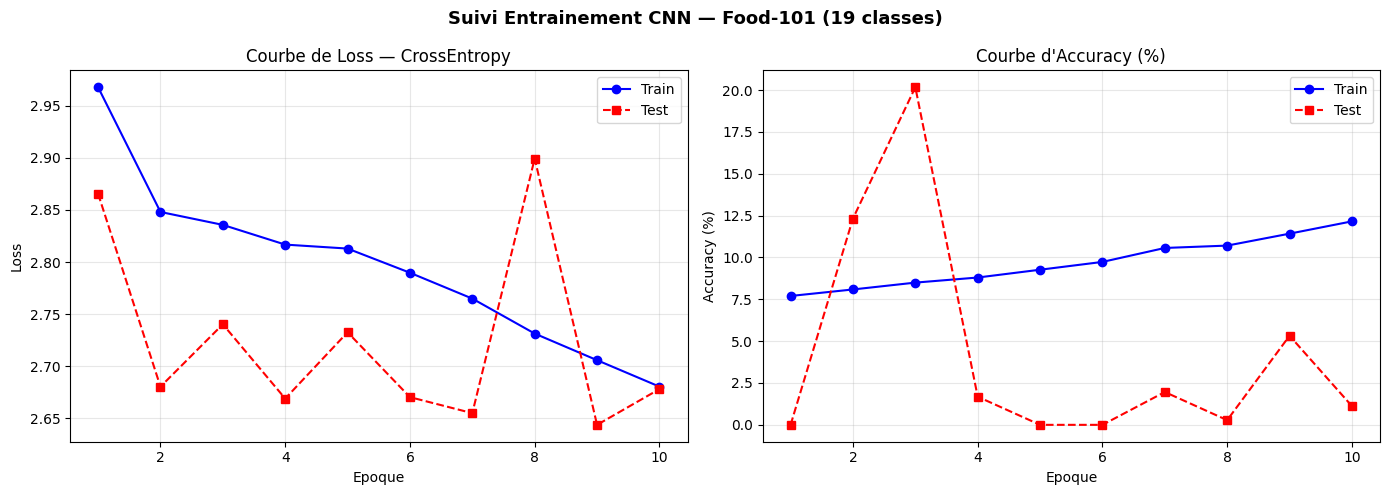


Resultats finaux :
  Meilleure Accuracy Train : 12.15%
  Meilleure Accuracy Test  : 20.17%


In [7]:
if NUM_CLASSES is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, EPOCHS + 1)

    ax1.plot(epochs_range, train_losses, 'b-o', label='Train')
    ax1.plot(epochs_range, test_losses,  'r--s', label='Test')
    ax1.set_title("Courbe de Loss — CrossEntropy")
    ax1.set_xlabel("Epoque"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs_range, train_accs, 'b-o', label='Train')
    ax2.plot(epochs_range, test_accs,  'r--s', label='Test')
    ax2.set_title("Courbe d'Accuracy (%)")
    ax2.set_xlabel("Epoque"); ax2.set_ylabel("Accuracy (%)")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(f"Suivi Entrainement CNN — Food-101 ({NUM_CLASSES} classes)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\nResultats finaux :")
    print(f"  Meilleure Accuracy Train : {max(train_accs):.2f}%")
    print(f"  Meilleure Accuracy Test  : {max(test_accs):.2f}%")


## Etape 6 — Visualisation des Feature Maps

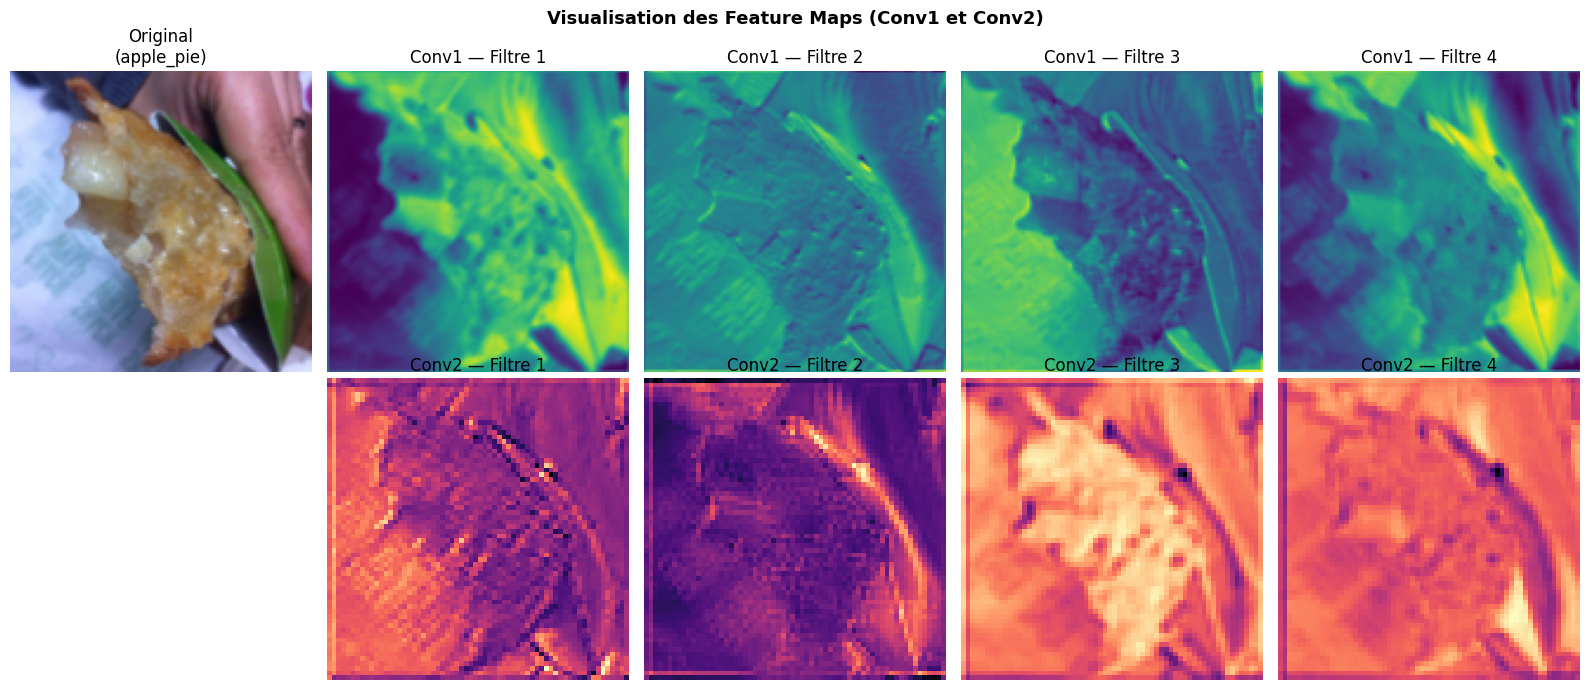

Conv1 : detection des bords/textures simples
Conv2 : detection de formes et motifs plus complexes


In [8]:
if NUM_CLASSES is not None:
    model_cnn.eval()
    dataiter = iter(test_loader_cnn)
    images, labels = next(dataiter)
    image_unique = images[0].unsqueeze(0).to(device)

    def denormaliser(img_tensor):
        img = img_tensor.cpu().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = std * img + mean
        return np.clip(img, 0, 1)

    with torch.no_grad():
        feat_maps_c1 = model_cnn.features[0](image_unique)   # Apres Conv1
        feat_maps_c2 = model_cnn.features[4](
            model_cnn.features[3](
                model_cnn.features[2](
                    model_cnn.features[1](feat_maps_c1))))    # Apres Conv2

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes[0, 0].imshow(denormaliser(images[0]))
    axes[0, 0].set_title(f"Original\n({dataset_test.classes[labels[0]]})")
    axes[0, 0].axis('off')

    for i in range(4):
        axes[0, i+1].imshow(feat_maps_c1[0, i].cpu().numpy(), cmap='viridis')
        axes[0, i+1].set_title(f"Conv1 — Filtre {i+1}")
        axes[0, i+1].axis('off')

    axes[1, 0].axis('off')
    for i in range(4):
        axes[1, i+1].imshow(feat_maps_c2[0, i].cpu().numpy(), cmap='magma')
        axes[1, i+1].set_title(f"Conv2 — Filtre {i+1}")
        axes[1, i+1].axis('off')

    plt.suptitle("Visualisation des Feature Maps (Conv1 et Conv2)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("Conv1 : detection des bords/textures simples")
    print("Conv2 : detection de formes et motifs plus complexes")


## Etape 7 — Sauvegarde du Modele

In [9]:
if NUM_CLASSES is not None:
    os.makedirs('models', exist_ok=True)
    chemin = 'models/best_cnn_food.pth'
    torch.save({
        'model_state_dict': model_cnn.state_dict(),
        'num_classes': NUM_CLASSES,
        'classes': dataset_train.classes,
        'best_test_acc': max(test_accs)
    }, chemin)
    print(f"Modele sauvegarde : {chemin}")
    print(f"Meilleure accuracy test : {max(test_accs):.2f}%")


Modele sauvegarde : models/best_cnn_food.pth
Meilleure accuracy test : 20.17%


## Conclusion
Ce notebook a presente une pipeline CNN complete sur Food-101 :

1. **Implementations manuelles** : correlation croisee, max/avg pooling verifies avec PyTorch
2. **Architecture propre** : BatchNorm + Dropout, nombre de classes detecte automatiquement
3. **Data augmentation** : RandomHorizontalFlip + ColorJitter pour reduire l'overfitting
4. **Suivi complet** : courbes loss/accuracy train vs test sur 10 epoques
5. **Feature maps** : visualisation des activations Conv1 (bords) et Conv2 (formes)
6. **Sauvegarde structuree** : checkpoint avec metadonnees (classes, best accuracy)
